In [1]:


# Import all libraries
import numpy as np #for numerical calculation
import pandas as pd #for data manipulation
import matplotlib.pyplot as plt #for plotting graph
from sklearn.datasets import load_iris #build-in-irisdataset
from sklearn.tree import DecisionTreeClassifier #ml algorithm
from sklearn.model_selection import train_test_split #data splitting
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree #for tree visualization

# Load dataset
#contain 150 flowers samples with 4 measurements each
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# See the data
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nSpecies: 0=Setosa, 1=Versicolor, 2=Virginica")

Dataset Shape: (150, 5)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Species: 0=Setosa, 1=Versicolor, 2=Virginica


In [2]:
# Split data into features (X) and target (y)
X = iris.data  # flower measurements
y = iris.target  # species labels

# Split into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [3]:
# Create and train the Decision Tree model
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

# Detailed report
print("\nDetailed Report:")
print(classification_report(y_test, y_pred,
      target_names=iris.target_names))

Model Accuracy: 100.0 %

Detailed Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



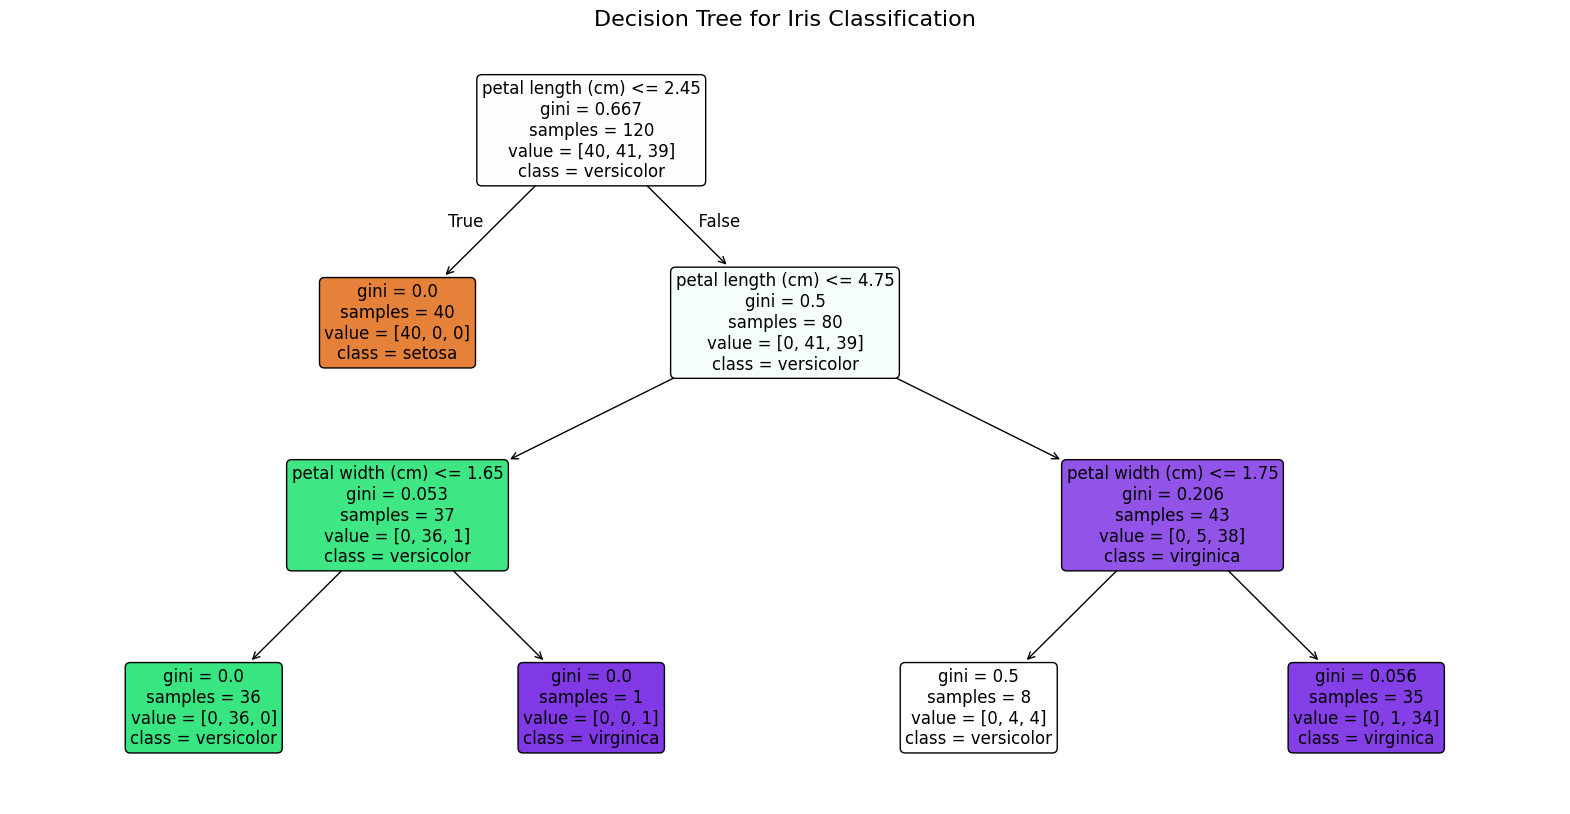

Tree saved!


In [4]:
# Visualize the Decision Tree
plt.figure(figsize=(20, 10))
tree.plot_tree(model,
               feature_names=iris.feature_names,
               class_names=iris.target_names,
               filled=True,
               rounded=True,
               fontsize=12)
plt.title("Decision Tree for Iris Classification", fontsize=16)
plt.savefig("decision_tree.png", dpi=150, bbox_inches='tight')
plt.show()
print("Tree saved!")

In [5]:
# Feature importance - what did the model find most useful?
print("Feature Importance:")
print("(Higher = more important for decision making)\n")
for name, importance in zip(iris.feature_names,
                             model.feature_importances_):
    bar = "█" * int(importance * 50)
    print(f"{name:25} {bar} {round(importance*100, 1)}%")

# Test with a new flower manually
print("\n--- Predicting a New Flower ---")
new_flower = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(new_flower)
print(f"Measurements: {new_flower[0]}")
print(f"Predicted Species: {iris.target_names[prediction[0]]}")

Feature Importance:
(Higher = more important for decision making)

sepal length (cm)          0.0%
sepal width (cm)           0.0%
petal length (cm)         ██████████████████████████████████████████████ 93.5%
petal width (cm)          ███ 6.5%

--- Predicting a New Flower ---
Measurements: [5.1, 3.5, 1.4, 0.2]
Predicted Species: setosa
